# Important Libraries

In [377]:
import pandas as pd 
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# Load The dataset

In [281]:
df = pd.read_csv('Ball_By_Ball_Match_Data.csv')

In [282]:
# see the first 5 rows of the dataset
df.head()

,ID,Innings,Overs,BallNumber,Batter,Bowler,NonStriker,ExtraType,BatsmanRun,ExtrasRun,TotalRun,IsWicketDelivery,PlayerOut,Kind,FieldersInvolved,BattingTeam
0,501208,1,0,1,S Sohal,Z Khan,S Dhawan,NaN,0,0,0,0,NaN,NaN,NaN,Deccan Chargers
1,501208,1,0,2,S Sohal,Z Khan,S Dhawan,NaN,1,0,1,0,NaN,NaN,NaN,Deccan Chargers
2,501208,1,0,3,S Dhawan,Z Khan,S Sohal,NaN,1,0,1,0,NaN,NaN,NaN,Deccan Chargers
3,501208,1,0,4,S Sohal,Z Khan,S Dhawan,NaN,0,0,0,0,NaN,NaN,NaN,Deccan Chargers
4,501208,1,0,5,S Sohal,Z Khan,S Dhawan,wides,0,1,1,0,NaN,NaN,NaN,Deccan Chargers


In [283]:
# see the last 5 rows of the dataset
df.tail()

,ID,Innings,Overs,BallNumber,Batter,Bowler,NonStriker,ExtraType,BatsmanRun,ExtrasRun,TotalRun,IsWicketDelivery,PlayerOut,Kind,FieldersInvolved,BattingTeam
295727,1359499,2,19,2,Abdul Samad,Arjun Tendulkar,B Kumar,NaN,1,0,1,1,Abdul Samad,run out,"Ishan Kishan,HR Shokeen",Sunrisers Hyderabad
295728,1359499,2,19,3,M Markande,Arjun Tendulkar,B Kumar,wides,0,1,1,0,NaN,NaN,NaN,Sunrisers Hyderabad
295729,1359499,2,19,4,M Markande,Arjun Tendulkar,B Kumar,NaN,2,0,2,0,NaN,NaN,NaN,Sunrisers Hyderabad
295730,1359499,2,19,5,M Markande,Arjun Tendulkar,B Kumar,legbyes,0,1,1,0,NaN,NaN,NaN,Sunrisers Hyderabad
295731,1359499,2,19,6,B Kumar,Arjun Tendulkar,M Markande,NaN,0,0,0,1,B Kumar,caught,RG Sharma,Sunrisers Hyderabad


In [284]:
# Dataset shape 
df.shape

(295732, 16)

In [285]:
# See the columns of the dataset
df.columns

Index(['ID', 'Innings', 'Overs', 'BallNumber', 'Batter', 'Bowler',
       'NonStriker', 'ExtraType', 'BatsmanRun', 'ExtrasRun', 'TotalRun',
       'IsWicketDelivery', 'PlayerOut', 'Kind', 'FieldersInvolved',
       'BattingTeam'],
      dtype='object')

In [286]:
# Dataset sample of 5 rows
df.sample(5)

,ID,Innings,Overs,BallNumber,Batter,Bowler,NonStriker,ExtraType,BatsmanRun,ExtrasRun,TotalRun,IsWicketDelivery,PlayerOut,Kind,FieldersInvolved,BattingTeam
175788,392182,2,5,5,T Henderson,R Vinay Kumar,NK Patel,NaN,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
262550,392210,2,12,2,IK Pathan,YK Pathan,Yuvraj Singh,NaN,1,0,1,0,NaN,NaN,NaN,Kings XI Punjab
281620,336016,2,3,4,JR Hopes,Z Khan,SE Marsh,NaN,6,0,6,0,NaN,NaN,NaN,Kings XI Punjab
159497,829763,1,12,6,AB de Villiers,TG Southee,KD Karthik,NaN,1,0,1,0,NaN,NaN,NaN,Royal Challengers Bangalore
268854,1136602,2,14,3,KS Williamson,TA Boult,S Dhawan,NaN,4,0,4,0,NaN,NaN,NaN,Sunrisers Hyderabad


In [287]:
# Dataset data types
df.dtypes

ID                   int64
Innings              int64
Overs                int64
BallNumber           int64
Batter              object
Bowler              object
NonStriker          object
ExtraType           object
BatsmanRun           int64
ExtrasRun            int64
TotalRun             int64
IsWicketDelivery     int64
PlayerOut           object
Kind                object
FieldersInvolved    object
BattingTeam         object
dtype: object

In [288]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295732 entries, 0 to 295731
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   ID                295732 non-null  int64 
 1   Innings           295732 non-null  int64 
 2   Overs             295732 non-null  int64 
 3   BallNumber        295732 non-null  int64 
 4   Batter            295732 non-null  object
 5   Bowler            295732 non-null  object
 6   NonStriker        295732 non-null  object
 7   ExtraType         16227 non-null   object
 8   BatsmanRun        295732 non-null  int64 
 9   ExtrasRun         295732 non-null  int64 
 10  TotalRun          295732 non-null  int64 
 11  IsWicketDelivery  295732 non-null  int64 
 12  PlayerOut         14705 non-null   object
 13  Kind              14705 non-null   object
 14  FieldersInvolved  10721 non-null   object
 15  BattingTeam       295732 non-null  object
dtypes: int64(8), object(8)
memory usage: 3

In [289]:
# dataset description
df.describe()

,ID,Innings,Overs,BallNumber,BatsmanRun,ExtrasRun,TotalRun,IsWicketDelivery
count,2.957320e+05,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000,295732.000000
mean,9.770551e+05,1.481781,9.190331,3.629195,1.290117,0.068336,1.358453,0.049724
std,3.953255e+05,0.499669,5.679690,1.819312,1.664418,0.342939,1.650191,0.217375
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483720e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,1.082639e+06,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.304103e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.535465e+06,2.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


## **EDA**

# Checking Missing value


In [290]:
df.isna().sum()

ID                       0
Innings                  0
Overs                    0
BallNumber               0
Batter                   0
Bowler                   0
NonStriker               0
ExtraType           279505
BatsmanRun               0
ExtrasRun                0
TotalRun                 0
IsWicketDelivery         0
PlayerOut           281027
Kind                281027
FieldersInvolved    285011
BattingTeam              0
dtype: int64

In this Dataset there are a certain number of missing value present Lets handle it

In [291]:
# Handle missing values for PlayerOut column

df['PlayerOut'].value_counts() # Checking the value counts of the PlayerOut column

df['PlayerOut'].fillna('No Player Out', inplace=True) # Filling missing values with 'No Player Out'|

C:\Users\INTEL\AppData\Local\Temp\ipykernel_16492\2027986539.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PlayerOut'].fillna('No Player Out', inplace=True) # Filling missing values with 'No Player Out'|


In [292]:
# Handle missing values for Extra_type column

df['ExtraType'].value_counts() # Checking the value counts of the ExtraType column

df['ExtraType'].fillna('No Extra', inplace=True) # Filling missing values with 'No Extra'

C:\Users\INTEL\AppData\Local\Temp\ipykernel_16492\610971035.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ExtraType'].fillna('No Extra', inplace=True) # Filling missing values with 'No Extra'


In [293]:
# Handle missing values for Kind column
df['Kind'].value_counts() # Checking the value counts of the Kind column

df['Kind'].fillna('', inplace=True) # Filling missing values with 'No Kind'

C:\Users\INTEL\AppData\Local\Temp\ipykernel_16492\1970595109.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Kind'].fillna('', inplace=True) # Filling missing values with 'No Kind'


In [294]:
# Handle missing values for FieldersInvolved column
df['FieldersInvolved'].value_counts() # Checking the value counts of the FieldersInvolved column

df['FieldersInvolved'].fillna('No Fielders Involved', inplace=True) # Filling missing values with 'No Fielders Involved'

C:\Users\INTEL\AppData\Local\Temp\ipykernel_16492\3533334782.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FieldersInvolved'].fillna('No Fielders Involved', inplace=True) # Filling missing values with 'No Fielders Involved'


In [295]:
# Checking for duplicates in the dataset
df.duplicated().sum() # Checking for duplicates in the dataset

np.int64(0)

## **Visualization**

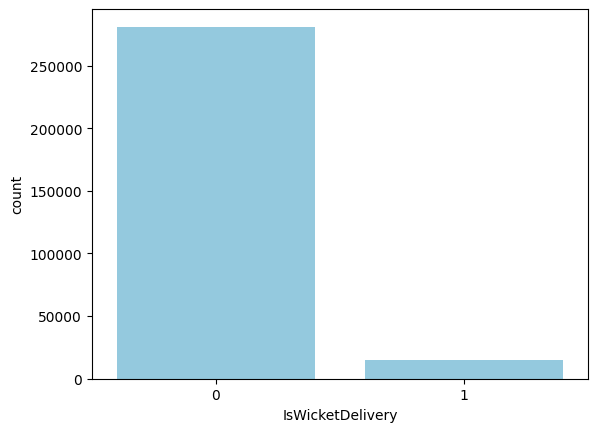

In [296]:
# Target Column destribution
sns.countplot(data=df, x='IsWicketDelivery', color='skyblue')
plt.show()

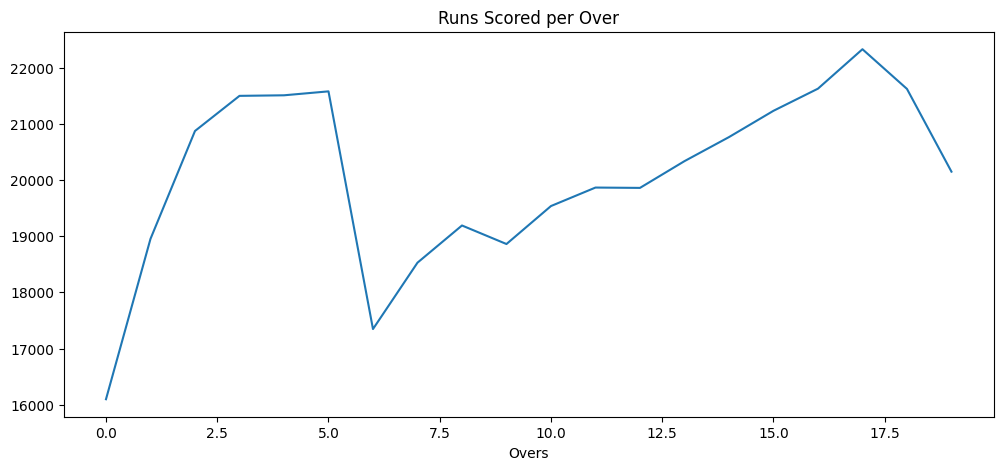

In [297]:
# Runs Scored per Over
runs_over = df.groupby('Overs')['TotalRun'].sum()

plt.figure(figsize=(12,5))
sns.lineplot(x=runs_over.index,
             y=runs_over.values)

plt.title("Runs Scored per Over")
plt.show()

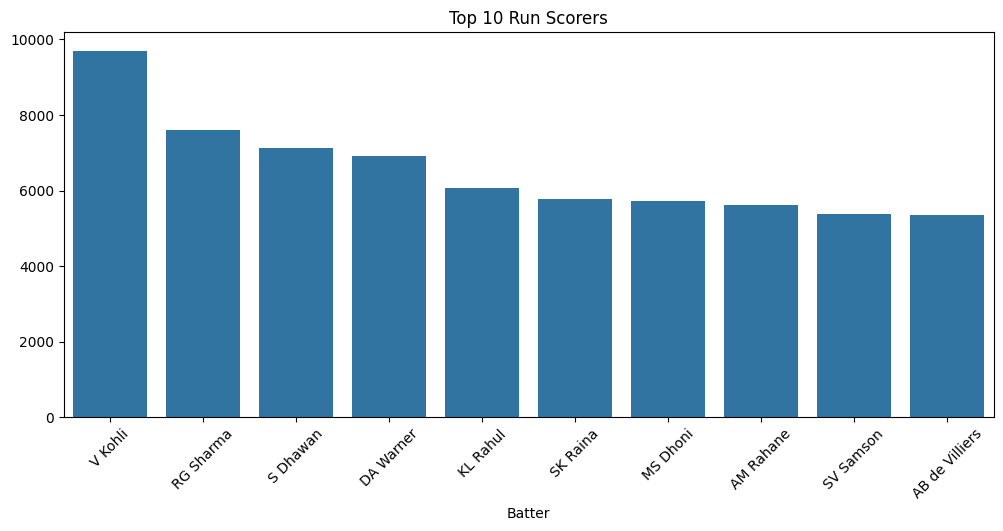

In [298]:
# Top Batsmen
top=df.groupby('Batter')['TotalRun'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top.index,y=top.values)

plt.xticks(rotation=45)

plt.title("Top 10 Run Scorers")

plt.show()

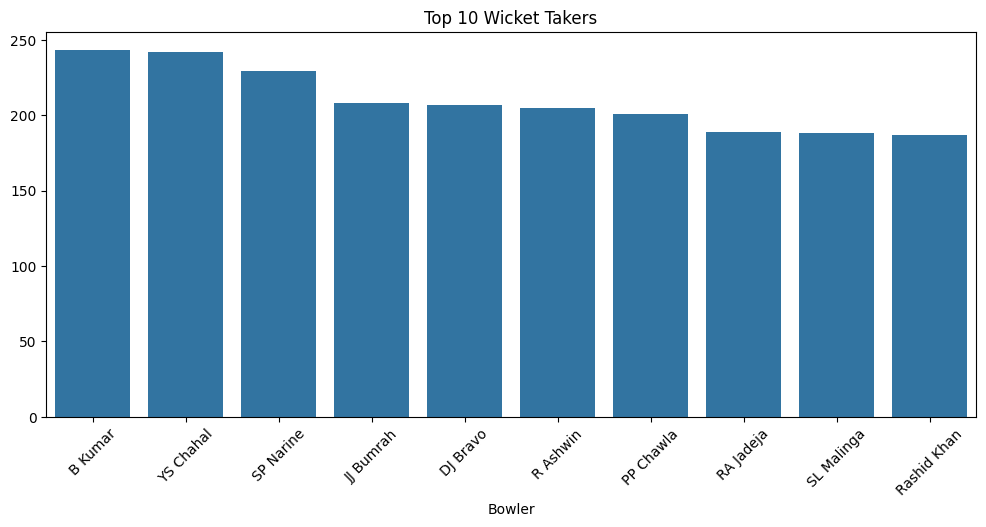

In [299]:
# top 10 blowers 
top=df.groupby('Bowler')['IsWicketDelivery'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top.index,y=top.values)

plt.xticks(rotation=45)

plt.title("Top 10 Wicket Takers")

plt.show()

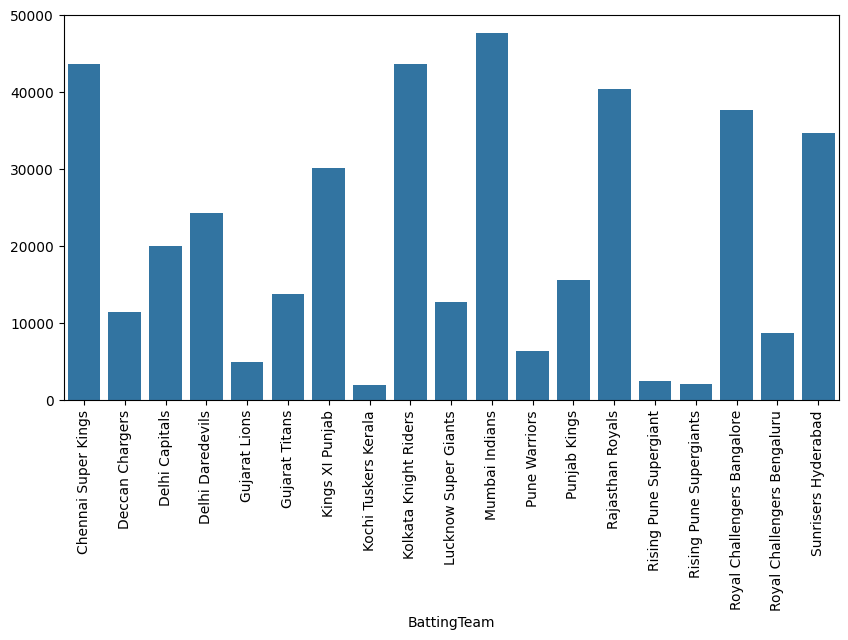

In [300]:
# Top team by run 
team=df.groupby('BattingTeam')['TotalRun'].sum()

plt.figure(figsize=(10,5))

sns.barplot(x=team.index,y=team.values)

plt.xticks(rotation=90)

plt.show()

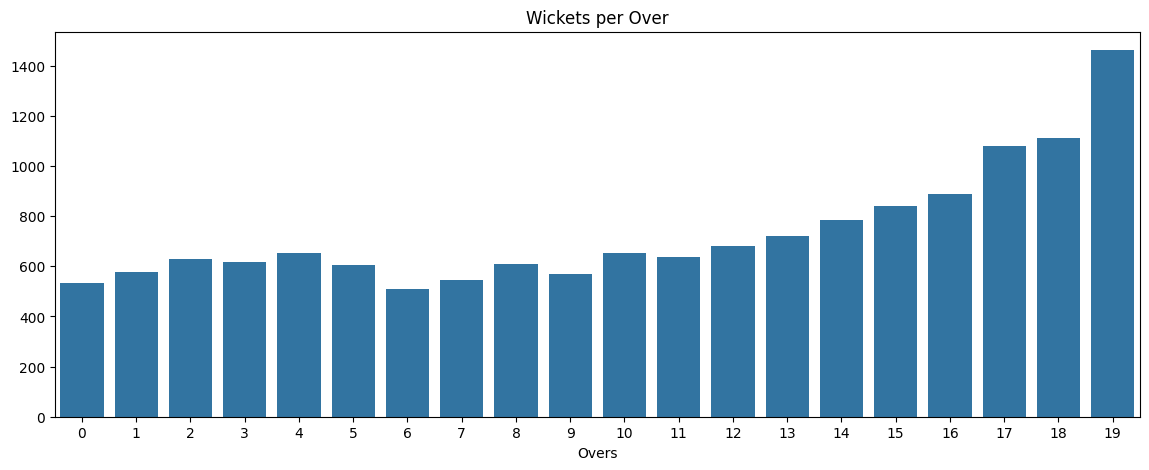

In [301]:
wk=df.groupby('Overs')['IsWicketDelivery'].sum()

plt.figure(figsize=(14,5))

sns.barplot(x=wk.index,y=wk.values)

plt.title("Wickets per Over")

plt.show()

C:\Users\INTEL\AppData\Local\Temp\ipykernel_16492\4013834315.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10.reset_index(),x='StrikeRate',y='Batter',palette='viridis')


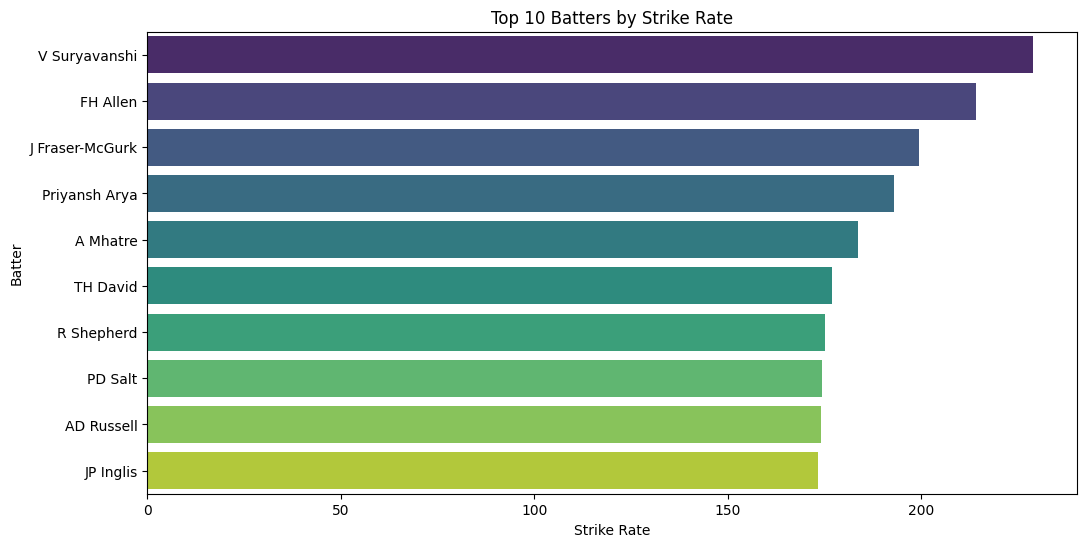

In [302]:
# Top 10 Batters by Strike Rate
# Count legal balls faced (exclude wides)
balls = (
    df[df['ExtraType'] != 'wides'].groupby('Batter').size().rename('Balls'))

# Total runs scored by each batter
runs = (
    df.groupby('Batter')['BatsmanRun'].sum().rename('Runs'))

# Combine runs and balls
strike_rate = pd.concat([runs, balls], axis=1)

# Calculate strike rate
strike_rate['StrikeRate'] = (
    strike_rate['Runs'] / strike_rate['Balls']) * 100

# Remove players with very few balls (recommended)
strike_rate = strike_rate[strike_rate['Balls'] >= 100]

# Top 10 strike rates
top10 = strike_rate.sort_values(by='StrikeRate',ascending=False).head(10)

# Ploting the top 10 batters by strike rate
plt.figure(figsize=(12,6))

sns.barplot(data=top10.reset_index(),x='StrikeRate',y='Batter',palette='viridis')

plt.title("Top 10 Batters by Strike Rate")
plt.xlabel("Strike Rate")
plt.ylabel("Batter")

plt.show()

C:\Users\INTEL\AppData\Local\Temp\ipykernel_16492\382708133.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


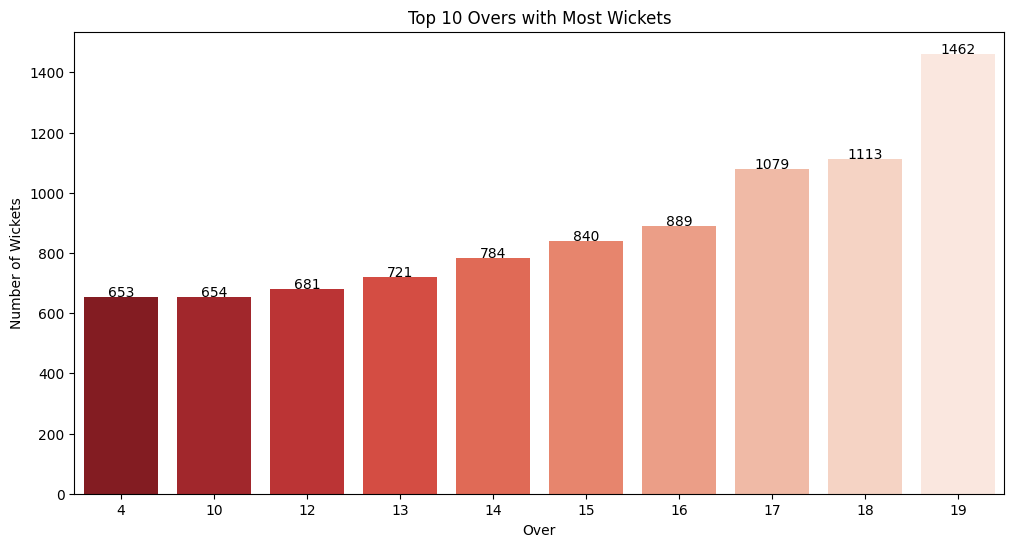

In [303]:
# Count wickets in each over
wickets_per_over = (
    df[df['IsWicketDelivery'] == 1]
    .groupby('Overs')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .sort_index()
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=wickets_per_over.index,
    y=wickets_per_over.values,
    palette="Reds_r"
)

# Add values on bars
for i, value in enumerate(wickets_per_over.values):ax.text(i, value + 2, str(value), ha='center', fontsize=10)

plt.title("Top 10 Overs with Most Wickets")
plt.xlabel("Over")
plt.ylabel("Number of Wickets")

plt.show()

C:\Users\INTEL\AppData\Local\Temp\ipykernel_16492\1024611769.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=death_wickets.values,y=death_wickets.index,palette='tab20')


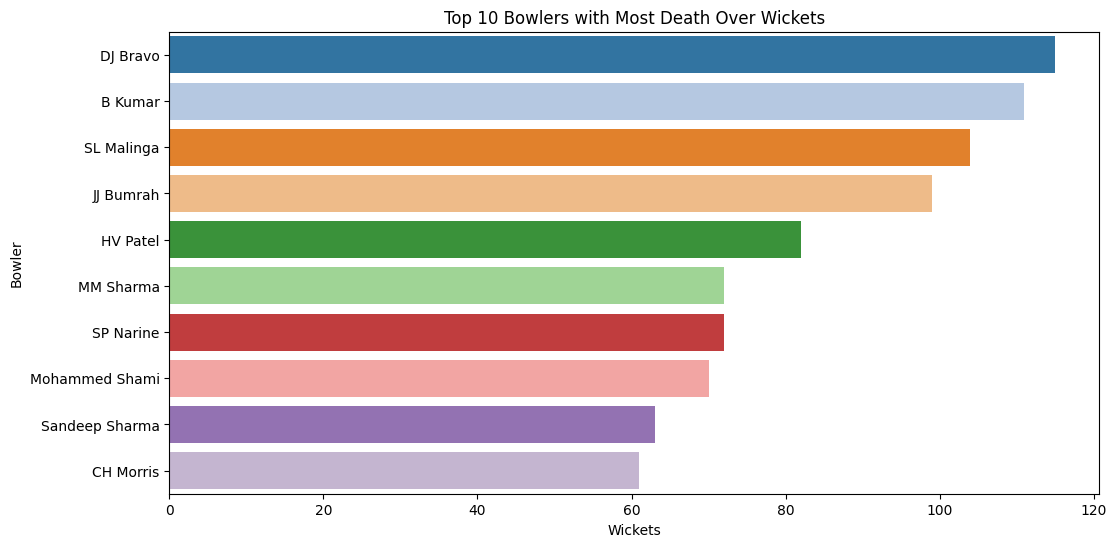

In [304]:
death_wickets = (
    df[(df['Overs'] >= 16) &
       (df['Overs'] <= 20) &
       (df['IsWicketDelivery'] == 1)].groupby('Bowler').size().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))

sns.barplot(x=death_wickets.values,y=death_wickets.index,palette='tab20')

plt.title("Top 10 Bowlers with Most Death Over Wickets")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.show()

C:\Users\INTEL\AppData\Local\Temp\ipykernel_16492\2219098568.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=death_runs.values,y=death_runs.index,palette='Set3')


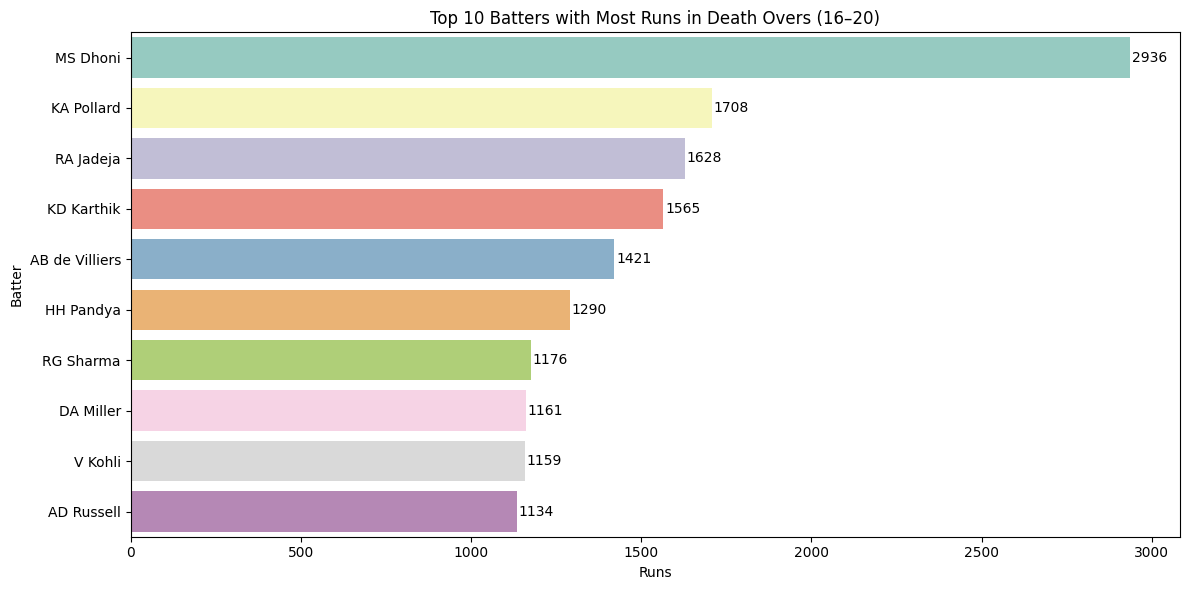

In [305]:
# Death overs (16-20)
death_runs = (df[(df['Overs'] >= 16) & (df['Overs'] <= 20)].groupby('Batter')['BatsmanRun'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))

ax = sns.barplot(x=death_runs.values,y=death_runs.index,palette='Set3')

# Add value labels
for i, value in enumerate(death_runs.values):
    ax.text(value + 5, i, str(value), va='center', fontsize=10)

plt.title("Top 10 Batters with Most Runs in Death Overs (16–20)")
plt.xlabel("Runs")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

C:\Users\INTEL\AppData\Local\Temp\ipykernel_16492\2344437544.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_sixes.values,y=top_sixes.index,palette='coolwarm')


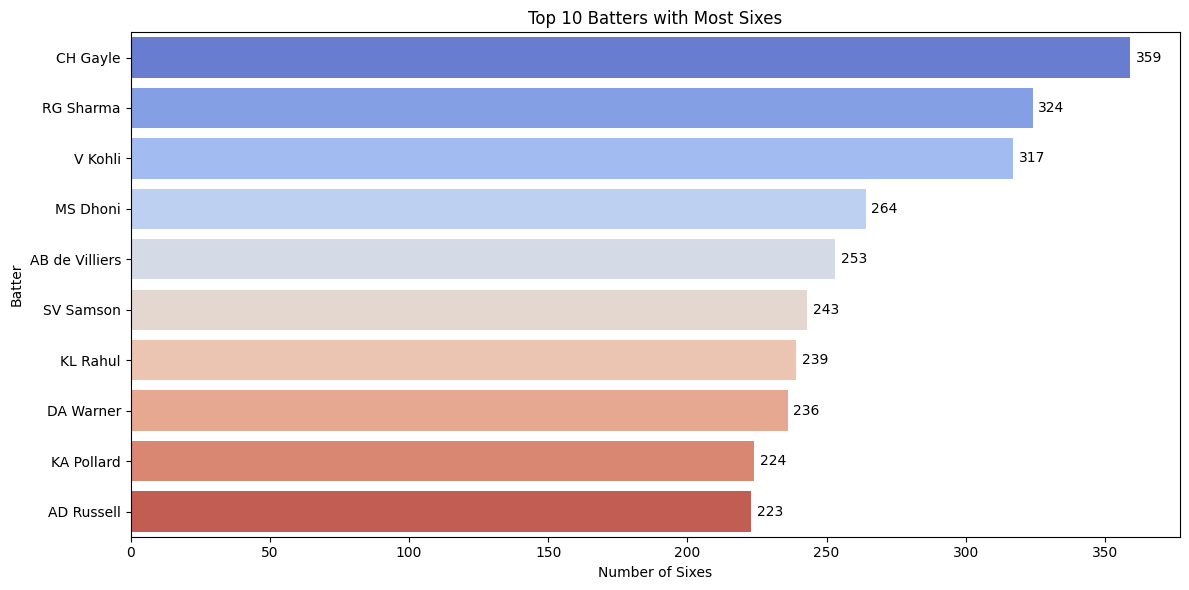

In [306]:
#top 10 batters with most sixes
top_sixes = (df[df['BatsmanRun']==6].groupby('Batter').size().sort_values(ascending=False).head(10))

# Ploting the top 10 batters with most sixes
plt.figure(figsize=(12, 6))

ax = sns.barplot(x=top_sixes.values,y=top_sixes.index,palette='coolwarm')

# Value labels
for i, value in enumerate(top_sixes.values):
    ax.text(value + 2, i, str(value), va='center', fontsize=10)

plt.title("Top 10 Batters with Most Sixes")
plt.xlabel("Number of Sixes")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

C:\Users\INTEL\AppData\Local\Temp\ipykernel_16492\866075896.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_fours.values,y=top_fours.index,palette='Paired')


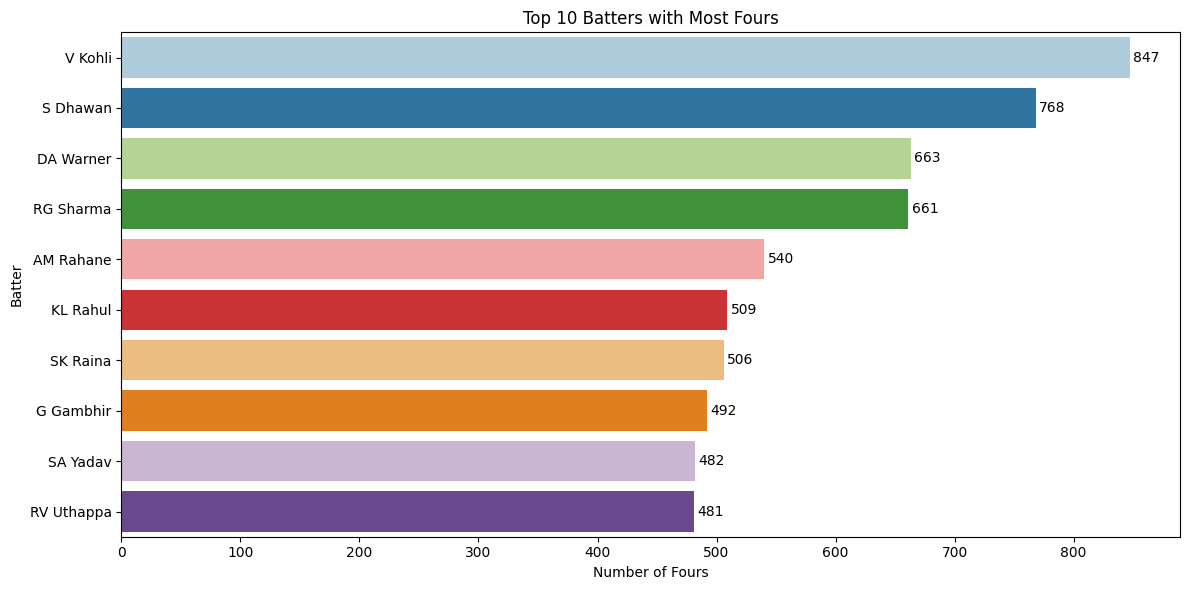

In [307]:
#top 10 batters with most fours
top_fours = (df[df['BatsmanRun'] == 4].groupby('Batter').size().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))

ax = sns.barplot(x=top_fours.values,y=top_fours.index,palette='Paired')

for i, value in enumerate(top_fours.values):
    ax.text(value + 3, i, str(value), va='center')

plt.title("Top 10 Batters with Most Fours")
plt.xlabel("Number of Fours")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

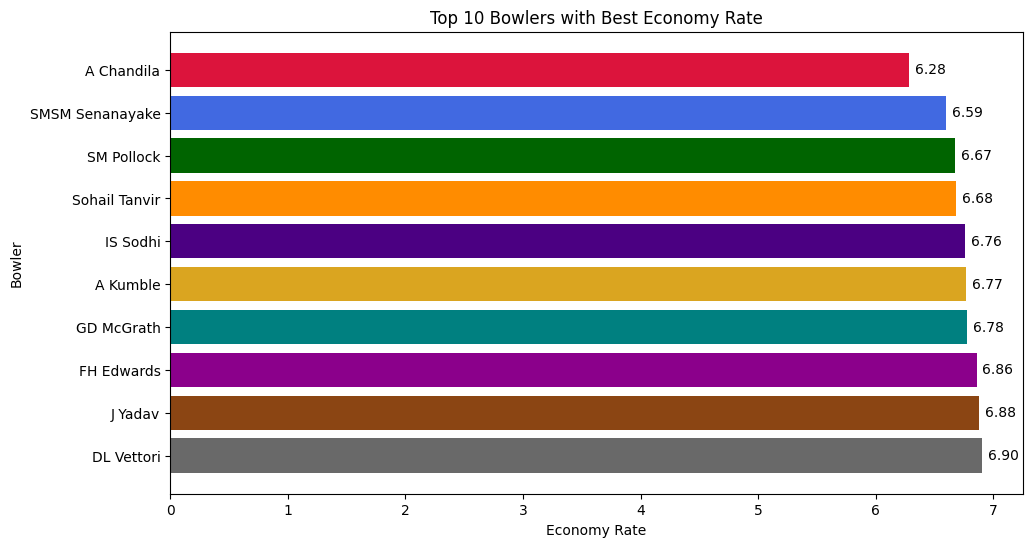

In [308]:
# Top 10 Bowlers with Best Economy Rate
# Count legal deliveries
ball_count = df[df["ExtraType"].isin(["wides", "noballs"]) == False] \
    .groupby("Bowler")["BallNumber"] \
    .count()

# Total runs conceded
run_count = df.groupby("Bowler")["TotalRun"].sum()

# Create a new dataframe
eco_df = pd.DataFrame({
    "Balls": ball_count,
    "Runs": run_count
})

# Convert balls to overs
eco_df["Overs"] = eco_df["Balls"] / 6

# Economy calculation
eco_df["Economy Rate"] = eco_df["Runs"] / eco_df["Overs"]

# Ignore bowlers with very few overs
eco_df = eco_df[eco_df["Overs"] >= 20]

# Take best 10
best_eco = eco_df.nsmallest(10, "Economy Rate")

# Plot
plt.figure(figsize=(11,6))

colors = colors = [
    "crimson",      
    "royalblue",    
    "darkgreen",    
    "darkorange",   
    "indigo",     
    "goldenrod",   
    "teal",       
    "darkmagenta",  
    "saddlebrown",  
    "dimgray"       
]

bars = plt.barh(
    best_eco.index,
    best_eco["Economy Rate"],
    color=colors
)


# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.gca().invert_yaxis()

plt.title("Top 10 Bowlers with Best Economy Rate")
plt.xlabel("Economy Rate")
plt.ylabel("Bowler")

plt.show()

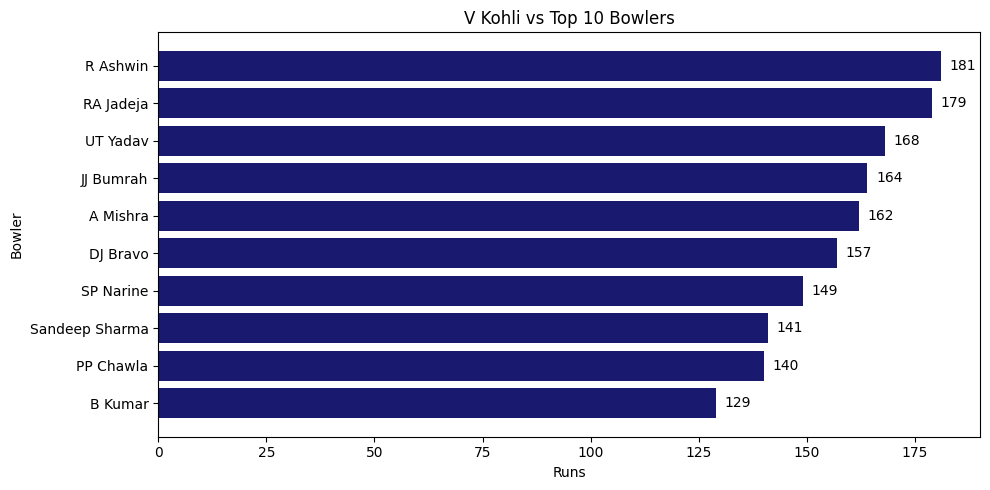

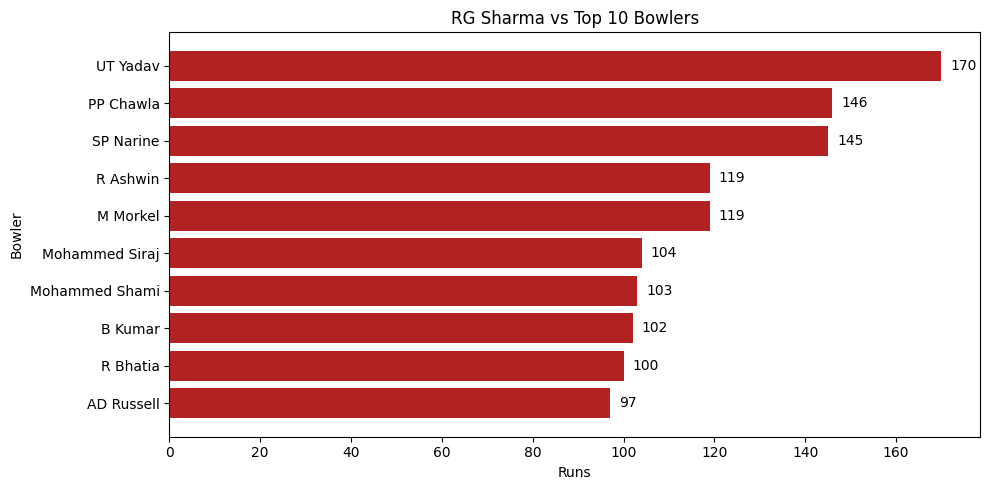

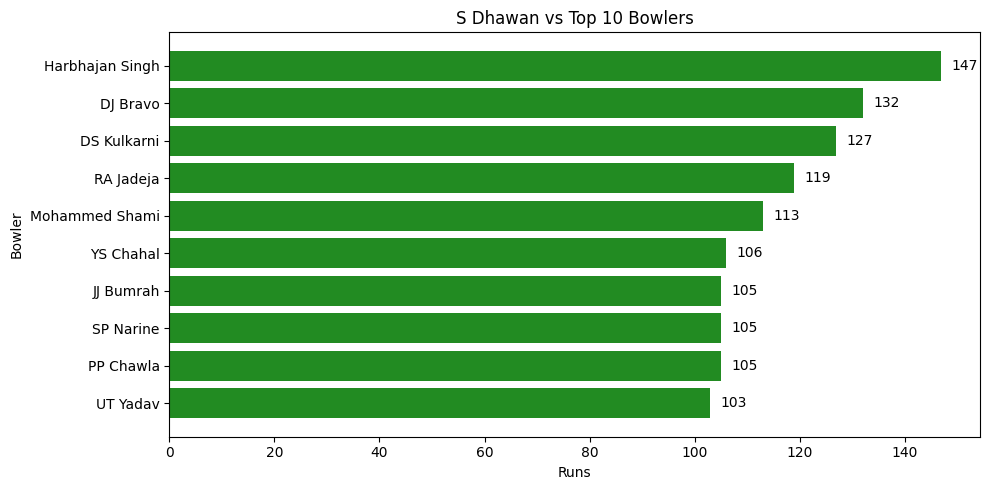

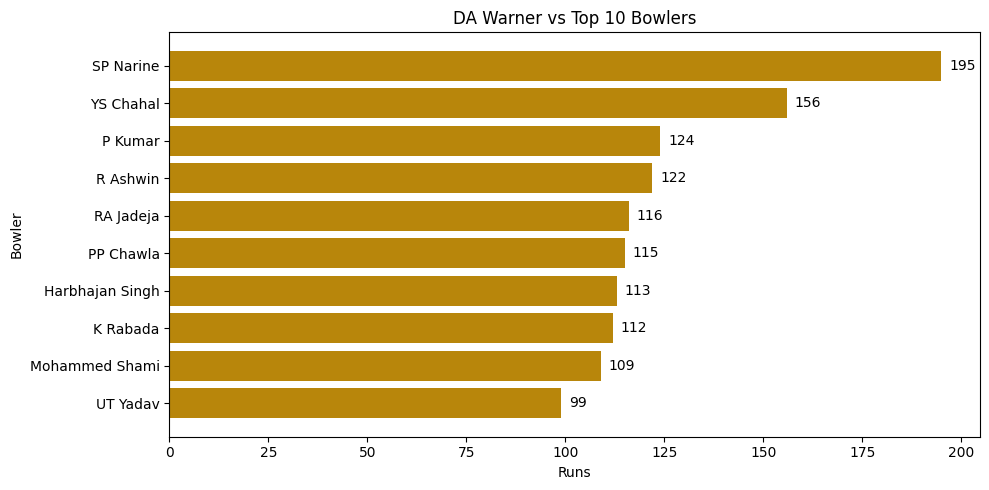

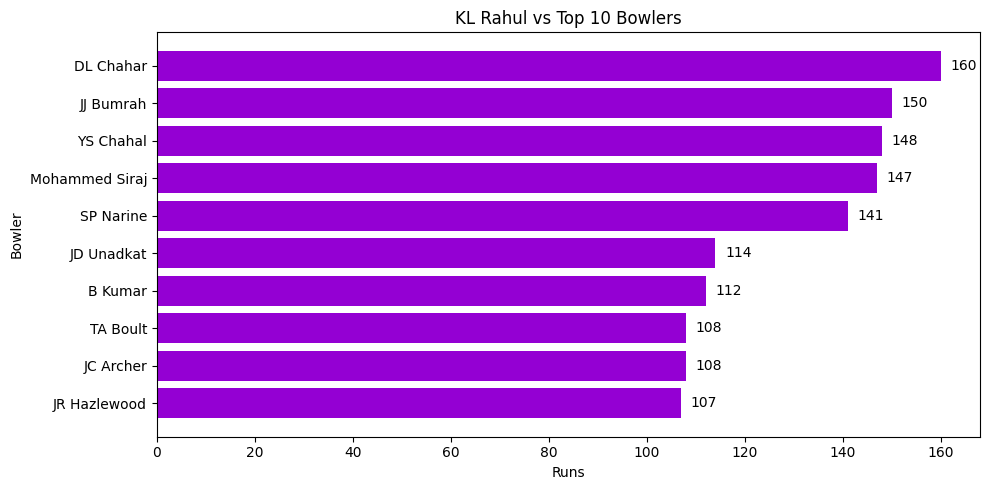

In [309]:
# Top 5 batters
top_batters = (
    df.groupby("Batter")["BatsmanRun"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# One color for each batter
colors = [
    "midnightblue",
    "firebrick",
    "forestgreen",
    "darkgoldenrod",
    "darkviolet"
]

for batter, color in zip(top_batters, colors):

    data = df[df["Batter"] == batter]

    runs = (
        data.groupby("Bowler")["BatsmanRun"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10,5))

    plt.barh(
        runs.index,
        runs.values,
        color=color
    )

    plt.gca().invert_yaxis()

    # Value labels
    for i, value in enumerate(runs.values):
        plt.text(value + 2, i, str(value), va='center')

    plt.title(f"{batter} vs Top 10 Bowlers")
    plt.xlabel("Runs")
    plt.ylabel("Bowler")

    plt.tight_layout()
    plt.show()

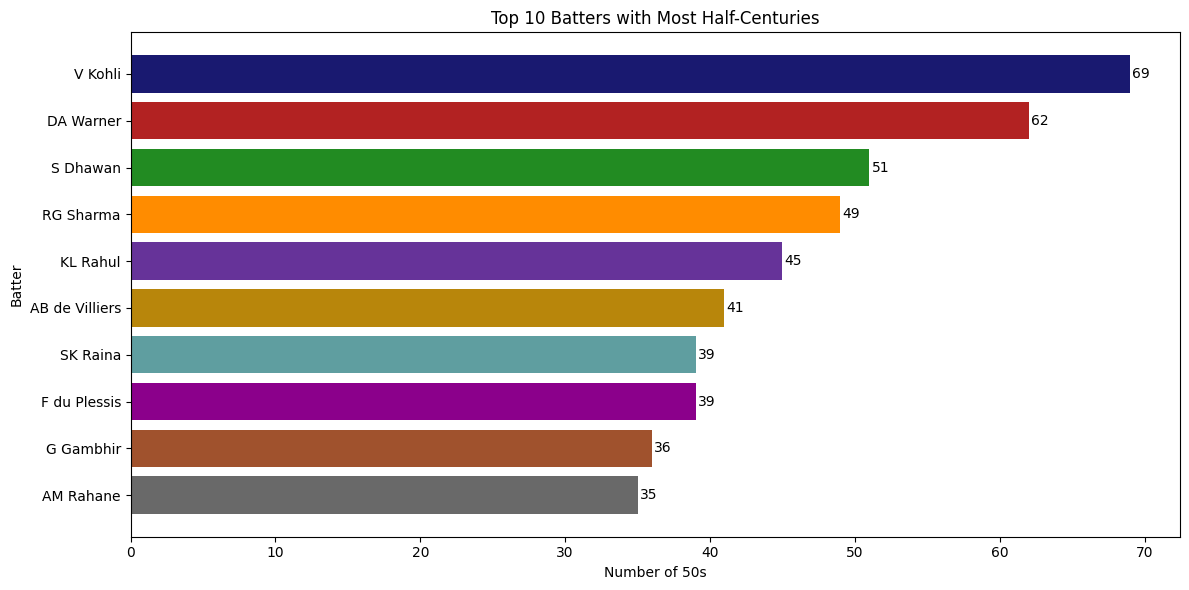

In [310]:
# Top 10 Batters with Most Half-Centuries
# Runs scored by each batter in each match
match_runs = (
    df.groupby(["ID", "Batter"])["BatsmanRun"].sum().reset_index())

# Select only 50-99 runs
fifties = match_runs[
    (match_runs["BatsmanRun"] >= 50) &
    (match_runs["BatsmanRun"] < 100)
]

# Count number of 50s for each batter
top_50s = (
    fifties.groupby("Batter").size().sort_values(ascending=False).head(10))

# Plot
plt.figure(figsize=(12,6))

bars = plt.barh(
    top_50s.index,
    top_50s.values,
    color=[
        "midnightblue",
        "firebrick",
        "forestgreen",
        "darkorange",
        "rebeccapurple",
        "darkgoldenrod",
        "cadetblue",
        "darkmagenta",
        "sienna",
        "dimgray"
    ]
)

# Show values
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.15,bar.get_y() + bar.get_height()/2,int(width),va="center")

plt.gca().invert_yaxis()

plt.title("Top 10 Batters with Most Half-Centuries")
plt.xlabel("Number of 50s")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

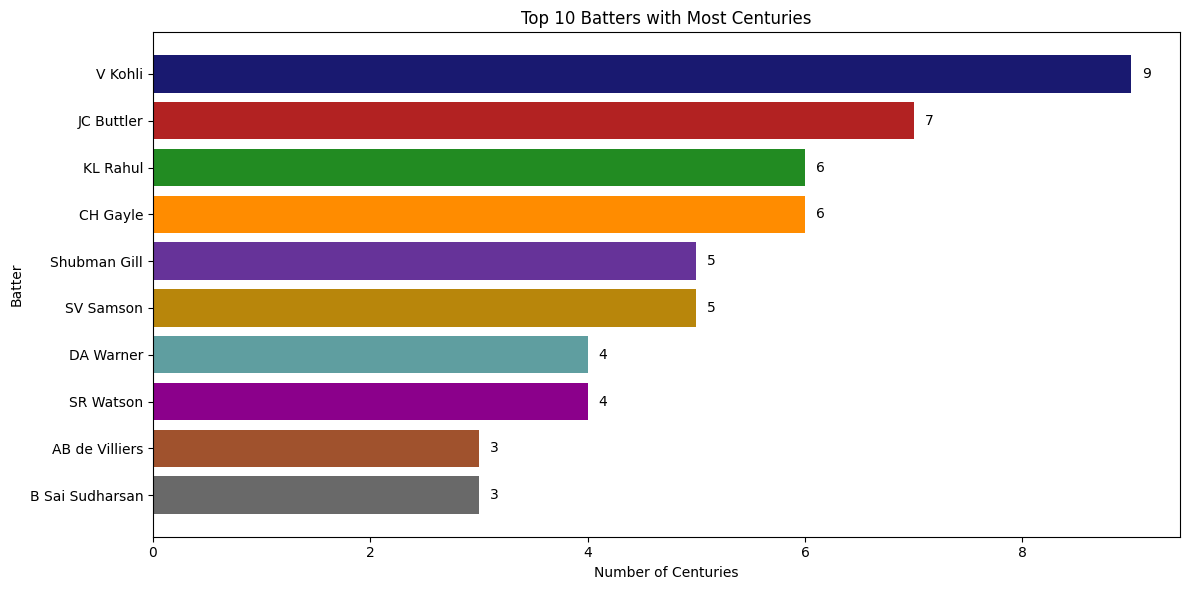

In [311]:
# Runs scored by each batter in each match
match_runs = (
    df.groupby(["ID", "Batter"])["BatsmanRun"].sum().reset_index())

# Filter centuries (100+ runs)
centuries = match_runs[match_runs["BatsmanRun"] >= 100]

# Count centuries for each batter
top_100s = (centuries.groupby("Batter").size().sort_values(ascending=False).head(10))

# Plot
plt.figure(figsize=(12,6))

bars = plt.barh(top_100s.index,top_100s.values,
    color=[
        "midnightblue",
        "firebrick",
        "forestgreen",
        "darkorange",
        "rebeccapurple",
        "darkgoldenrod",
        "cadetblue",
        "darkmagenta",
        "sienna",
        "dimgray"
    ]
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1,bar.get_y() + bar.get_height()/2,int(width),va="center")

plt.gca().invert_yaxis()

plt.title("Top 10 Batters with Most Centuries")
plt.xlabel("Number of Centuries")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

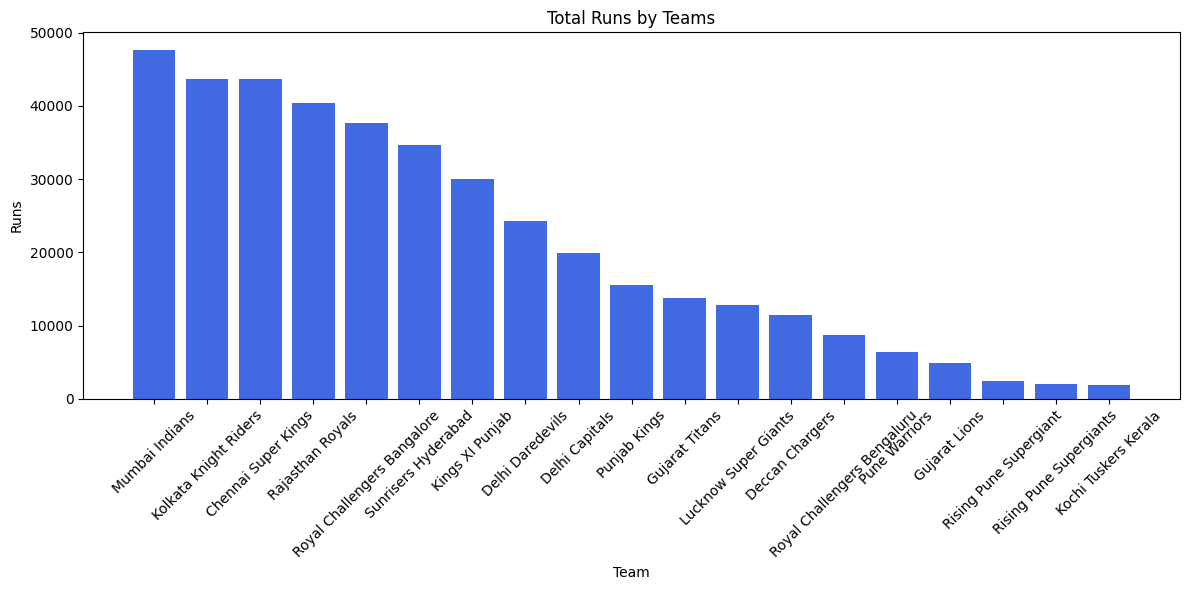

In [312]:
# Top 10 Teams with Most Runs
team_runs = (
    df.groupby("BattingTeam")["TotalRun"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(team_runs.index, team_runs.values, color="royalblue")

plt.xticks(rotation=45)
plt.title("Total Runs by Teams")
plt.xlabel("Team")
plt.ylabel("Runs")

plt.tight_layout()
plt.show()

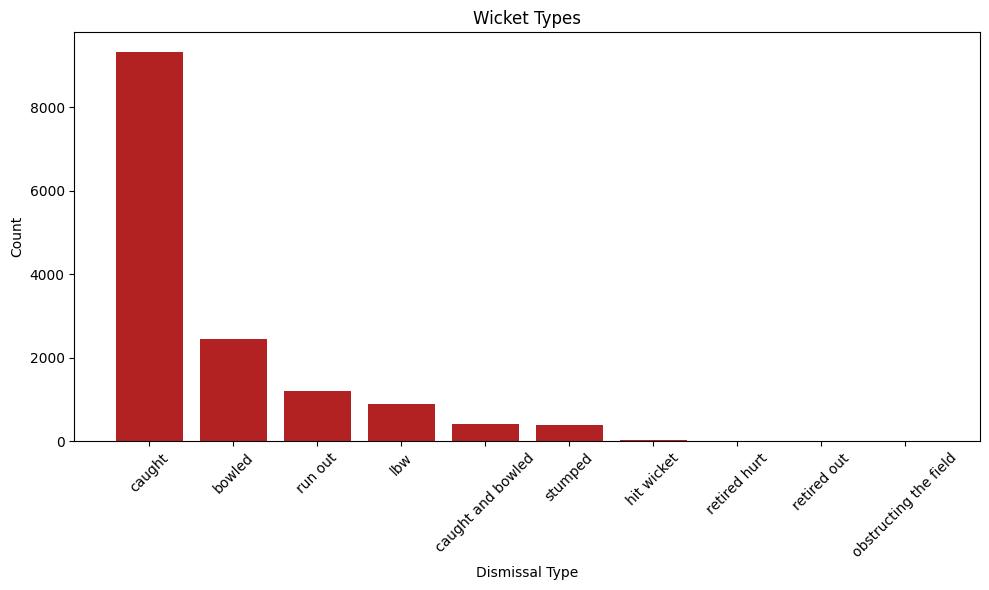

In [313]:
wicket_type = (
    df[df["IsWicketDelivery"] == 1]["Kind"]
    .value_counts()
)

plt.figure(figsize=(10,6))

plt.bar(
    wicket_type.index,
    wicket_type.values,
    color="firebrick"
)

plt.xticks(rotation=45)
plt.title("Wicket Types")
plt.xlabel("Dismissal Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

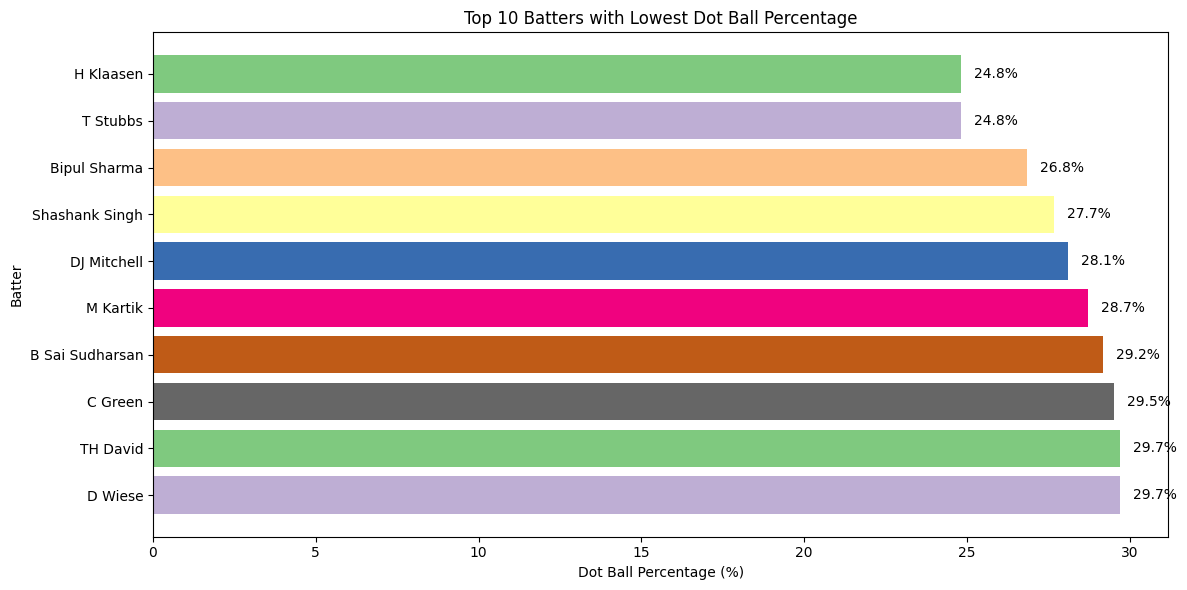

In [314]:
# Top 10 Batters with Lowest Dot Ball Percentage
# Legal balls faced (excluding wides)
balls = (
    df[df["ExtraType"] != "wides"]
    .groupby("Batter")
    .size()
)

# Dot balls
dots = (
    df[
        (df["BatsmanRun"] == 0) &
        (df["ExtraType"] != "wides")
    ]
    .groupby("Batter")
    .size()
)

# Create DataFrame
dot_df = pd.DataFrame({
    "Balls": balls,
    "Dots": dots
}).fillna(0)

# Dot Ball Percentage
dot_df["Dot_Percentage"] = (
    dot_df["Dots"] / dot_df["Balls"]
) * 100

# Filter batters with at least 100 balls
dot_df = dot_df[dot_df["Balls"] >= 100]

# Top 10 Lowest Dot Ball Percentage
top_dot = (
    dot_df.sort_values("Dot_Percentage")
    .head(10)
)

# Plot
plt.figure(figsize=(12,6))

colors = sns.color_palette("Accent", len(top_dot))

bars = plt.barh(
    top_dot.index,
    top_dot["Dot_Percentage"],
    color=colors
)

# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.4,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

plt.gca().invert_yaxis()

plt.title("Top 10 Batters with Lowest Dot Ball Percentage")
plt.xlabel("Dot Ball Percentage (%)")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

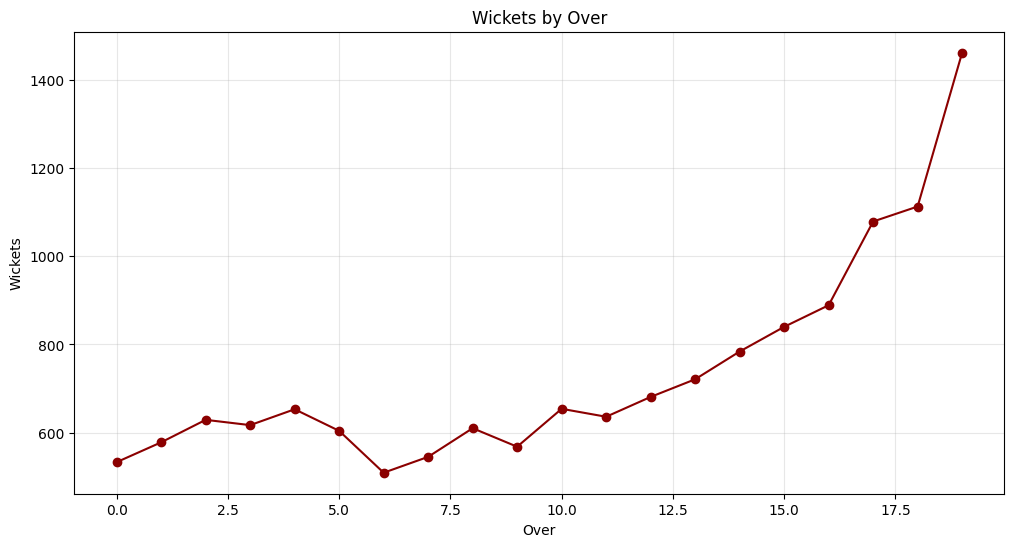

In [315]:
wickets = (
    df[df["IsWicketDelivery"] == 1]
    .groupby("Overs")
    .size()
)

plt.figure(figsize=(12,6))

plt.plot(
    wickets.index,
    wickets.values,
    marker="o",
    color="darkred"
)

plt.grid(alpha=0.3)

plt.title("Wickets by Over")

plt.xlabel("Over")

plt.ylabel("Wickets")

plt.show()

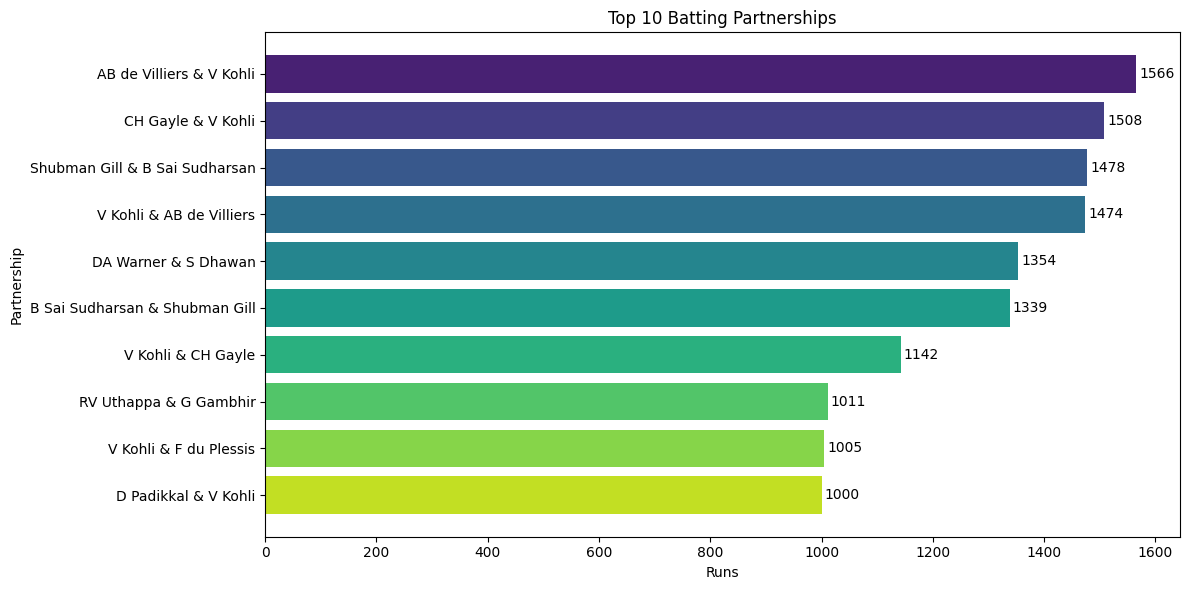

In [316]:
# Top 10 Partnerships
partnership = (
    df.groupby(["Batter", "NonStriker"])["BatsmanRun"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

# Viridis color palette
colors = sns.color_palette("viridis", len(partnership))

bars = plt.barh(
    partnership["Batter"] + " & " + partnership["NonStriker"],
    partnership["BatsmanRun"],
    color=colors
)

# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        int(width),
        va="center",
        fontsize=10
    )

plt.gca().invert_yaxis()

plt.title("Top 10 Batting Partnerships")
plt.xlabel("Runs")
plt.ylabel("Partnership")

plt.tight_layout()
plt.show()

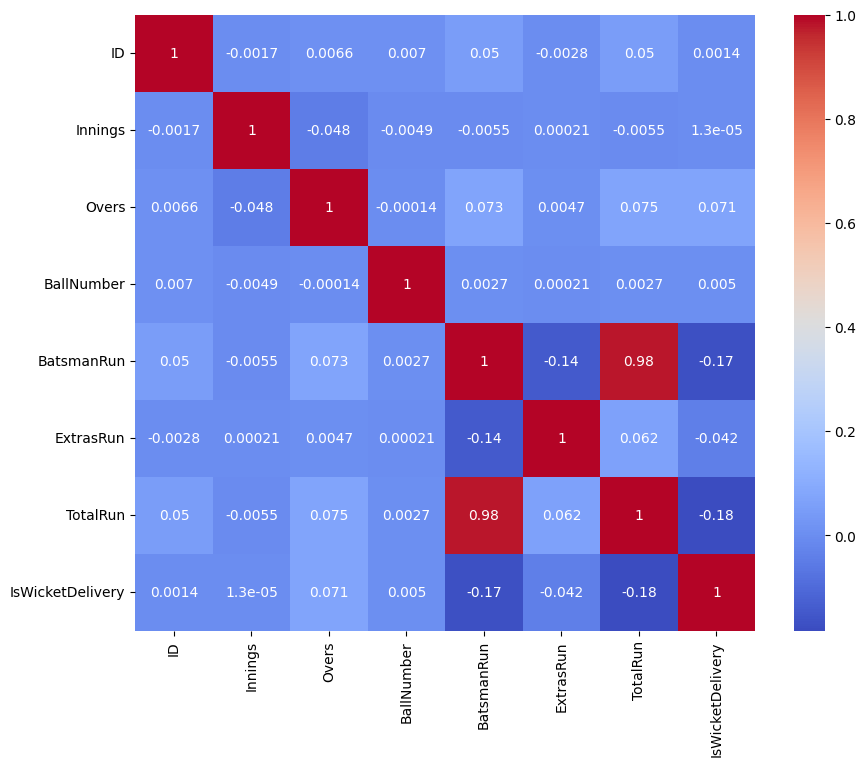

In [317]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

## **Feature Engineering**

In [318]:
# Boundaries
df["Boundaries"] = df["BatsmanRun"].isin([4, 6]).astype(int)

In [319]:
# Over Phase 
def over_phase(over):
    if over <= 6:
        return "Powerplay"
    elif over <= 15:
        return "Middle"
    else:
        return "Death"

df["OverPhase"] = df["Overs"].apply(over_phase)

In [320]:
# Powerplay Over Phase Analysis
df["IsPowerplay"] = (df["Overs"] <= 6).astype(int)

In [321]:
# Current Ball Number
df["CurrentBall"] = (df["Overs"] - 1) * 6 + df["BallNumber"]

In [322]:
# Over Progression
df["OverProgress"] = round(df["Overs"] + df["BallNumber"] / 6, 2)

In [323]:
# Death Overs Analysis
df["IsDeathOver"] = (df["Overs"] >= 16).astype(int)

In [324]:
# Batting Balling pair
df["Battle"] = (df["Batter"] + "_" + df["Bowler"])

In [325]:
# Current Score
df["CurrentScore"] = (
    df.groupby(["ID", "Innings"])["TotalRun"]
      .cumsum()
      .shift(fill_value=0)
)

In [326]:
# Curren tWickets
df["CurrentWickets"] = (
    df.groupby(["ID","Innings"])["IsWicketDelivery"]
      .cumsum()
      .shift(fill_value=0)
)


In [327]:
# Ball Faced
df["BallsFaced"] = (df.groupby(["ID", "Innings"]).cumcount())

In [328]:
# Current Runrate 
df["CurrentRunRate"] = np.where(df["BallsFaced"]==0,0,(df["CurrentScore"]*6)/df["BallsFaced"])

df["CurrentRunRate"] = df["CurrentRunRate"].round(2)

In [329]:
# Dot Ball 
df["IsDotBall"] = (df["TotalRun"] == 0).astype(int)

In [330]:
# Dot Ball Rate
df["DotBallRate"] = np.where(df["BallsFaced"] == 0,0,df.groupby(["ID", "Innings"])["IsDotBall"].cumsum() / df["BallsFaced"]).round(2)

In [331]:
# Middle over
df["IsMiddleOver"] = ((df["Overs"] >= 7) &(df["Overs"] <= 15)).astype(int)

In [332]:
# Boundary Rate
df["BoundaryRate"] = np.where(df["BallsFaced"] == 0,0,df["Boundaries"] / df["BallsFaced"])

df["BoundaryRate"] = df["BoundaryRate"].round(2)

In [333]:
# Bowler Economy Rate


# Runs conceded before current ball
df["BowlerRuns"] = (df.groupby(["ID", "Innings", "Bowler"])["TotalRun"].cumsum().shift(fill_value=0))

# Balls bowled before current ball
df["BowlerBalls"] = (df.groupby(["ID", "Innings", "Bowler"]).cumcount())

# Economy Rate
df["BowlerEconomy"] = np.where(df["BowlerBalls"] == 0,0,(df["BowlerRuns"] * 6) / df["BowlerBalls"])

df["BowlerEconomy"] = df["BowlerEconomy"].round(2)

In [334]:
# Batter Strike Rate
# Batter Runs
df["BatterRuns"] = (df.groupby(["ID", "Innings", "Batter"])["BatsmanRun"].cumsum())

# Batter Balls
df["BatterBalls"] = (df.groupby(["ID", "Innings", "Batter"]).cumcount() + 1)

# Strike Rate
df["StrikeRate"] = (df["BatterRuns"] * 100) / df["BatterBalls"]

df["StrikeRate"] = df["StrikeRate"].round(2)

In [335]:
# Rollin Runs 6 (Previous 6 Balls)
df["RollingRuns6"] = (df.groupby(["ID", "Innings"])["TotalRun"].transform(lambda x: x.shift(1).rolling(window=6, min_periods=1).sum()).fillna(0)
)

In [336]:
# RollingWickets6 (Previous 6 Balls)
df["RollingWickets6"] = (df.groupby(["ID", "Innings"])["IsWicketDelivery"].transform(lambda x: x.shift(1).rolling(window=6, min_periods=1).sum()).fillna(0))

In [337]:
# Batter Form (last 30 deliveries)
df["BatterForm"] = (df.groupby(["ID", "Innings", "Batter"])["BatsmanRun"].transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).sum()).fillna(0))

In [338]:
# Bowler Form (last 30 deliveries)
df["BowlerRunsLast30"] = (df.groupby(["ID", "Innings", "Bowler"])["TotalRun"].transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).sum()).fillna(0))

In [339]:
df.loc[100:110, [
    "TotalRun",
    "CurrentScore",
    "RollingRuns6"
]]

,TotalRun,CurrentScore,RollingRuns6
100,1,129,16.0
101,4,130,16.0
102,4,134,19.0
103,4,138,17.0
104,1,142,15.0
105,1,143,15.0
106,1,144,15.0
107,2,145,15.0
108,1,147,13.0
109,0,148,10.0


In [340]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,295732.0,977055.109440,395325.537156,335982.00,548372.00,1082639.00,1304103.00,1535465.00
Innings,295732.0,1.481781,0.499669,1.00,1.00,1.00,2.00,2.00
Overs,295732.0,9.190331,5.679690,0.00,4.00,9.00,14.00,19.00
BallNumber,295732.0,3.629195,1.819312,1.00,2.00,4.00,5.00,11.00
BatsmanRun,295732.0,1.290117,1.664418,0.00,0.00,1.00,1.00,6.00
ExtrasRun,295732.0,0.068336,0.342939,0.00,0.00,0.00,0.00,7.00
TotalRun,295732.0,1.358453,1.650191,0.00,0.00,1.00,1.00,7.00
IsWicketDelivery,295732.0,0.049724,0.217375,0.00,0.00,0.00,0.00,1.00
Boundaries,295732.0,0.169836,0.375489,0.00,0.00,0.00,0.00,1.00
IsPowerplay,295732.0,0.365720,0.481632,0.00,0.00,0.00,1.00,1.00


In [341]:
df.shape

(295732, 41)

## **Dataset Spliting**

In [342]:
x = df.drop(columns=["ID","Boundaries","TotalRun","BatsmanRun","ExtrasRun","PlayerOut","Kind","FieldersInvolved","CurrentScore","BowlerRuns","BatterRuns","StrikeRate","BoundaryRate","IsDotBall"],axis=1)
y = df['Boundaries']

## **Performing Encoding**

## Low & High Cardinality divide

In [343]:
low_cardinality = ["BattingTeam","OverPhase","ExtraType"]

high_cardinality = ["Batter","Bowler","NonStriker","Battle"]

## Performing Frequency Encoding for high_cardinality columns 

In [344]:
for col in high_cardinality:
    frequency = x[col].value_counts(normalize=True)
    x[col] = x[col].map(frequency)

## Performing Onehot Encoding for low_cardinality columns 

In [345]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown="ignore")

encoded = encoder.fit_transform(x[low_cardinality])

encoded_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out(low_cardinality),index=x.index)

## Concatenate

In [346]:
x = pd.concat([x.drop(columns=low_cardinality),encoded_df],axis=1)

In [347]:
print(f"Final Shape : {x.shape}")
x.head()

Final Shape : (295732, 55)


,Innings,Overs,BallNumber,Batter,Bowler,NonStriker,IsWicketDelivery,IsPowerplay,CurrentBall,OverProgress,...,OverPhase_Powerplay,ExtraType_No Extra,ExtraType_byes,"ExtraType_byes,noballs",ExtraType_legbyes,"ExtraType_legbyes,noballs",ExtraType_noballs,ExtraType_penalty,"ExtraType_penalty,wides",ExtraType_wides
0,1,0,1,0.001052,0.007696,0.020093,0,1,-5,0.17,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0,2,0.001052,0.007696,0.020093,0,1,-4,0.33,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,3,0.018540,0.007696,0.000825,0,1,-3,0.50,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,4,0.001052,0.007696,0.020093,0,1,-2,0.67,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,0,5,0.001052,0.007696,0.020093,0,1,-1,0.83,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## **Performing Train-Test Split**

In [348]:
xtrain ,xtest, ytrain,ytest = train_test_split(x,y,test_size=.20,random_state=42)

## **Feature Importance**

In [354]:
importance = pd.DataFrame({"Feature": xtrain.columns,"Importance": model_xgboost.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)

print(importance.head(20))

                      Feature  Importance
46         ExtraType_No Extra    0.351627
6            IsWicketDelivery    0.224973
16               IsMiddleOver    0.083335
51          ExtraType_noballs    0.076830
1                       Overs    0.028289
54            ExtraType_wides    0.025187
21            RollingWickets6    0.013197
15                DotBallRate    0.012591
49          ExtraType_legbyes    0.010914
22                 BatterForm    0.009477
19                BatterBalls    0.009175
13                 BallsFaced    0.008409
14             CurrentRunRate    0.007288
12             CurrentWickets    0.007052
8                 CurrentBall    0.006466
35  BattingTeam_Pune Warriors    0.005513
4                      Bowler    0.005500
36   BattingTeam_Punjab Kings    0.005208
3                      Batter    0.005060
11                     Battle    0.004984


## **Target Variable Distribution**

In [356]:
print(y.value_counts())

print(y.value_counts(normalize=True) * 100)

Boundaries
0    245506
1     50226
Name: count, dtype: int64
Boundaries
0    83.01638
1    16.98362
Name: proportion, dtype: float64


## **Performing Models and Evaluation**|

## **XGBoost**

In [349]:
xg = XGBClassifier() #Create object for xgboost classifier

model_xgboost = xg.fit(xtrain,ytrain)

#Train Score
print("Training Score : ", model_xgboost.score(xtrain,ytrain)*100)
print("\n")

#Test Score 
print("Test Score : " ,model_xgboost.score(xtest,ytest)*100)

#prediction 

y_pred_xg = xg.predict(xtest)

Training Score :  83.4651393790815


Test Score :  82.81907789067915


## Model Evaluation

Accuracy Score :  82.81907789067915
Classification Report                precision    recall  f1-score   support

           0       0.83      1.00      0.91     49038
           1       0.42      0.01      0.03     10109

    accuracy                           0.83     59147
   macro avg       0.62      0.50      0.47     59147
weighted avg       0.76      0.83      0.76     59147



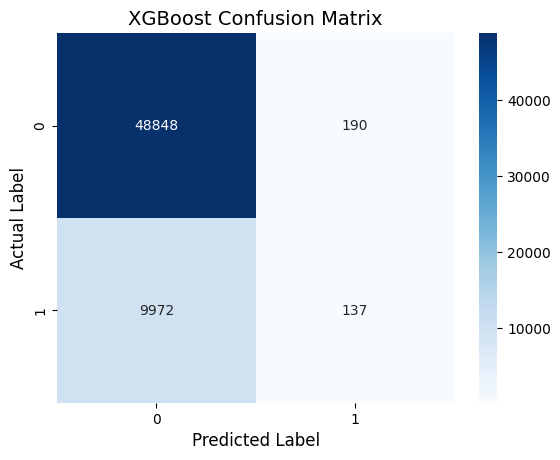

In [372]:
# Accuracy Score 
print("Accuracy Score : ", accuracy_score(ytest,y_pred_xg)*100)

#classification report 
print("Classification Report ", classification_report(ytest,y_pred_xg))

#Confusin Matrix
cm = confusion_matrix(ytest,y_pred_xg)

#Heatmap For Confusion Matrix
sns.heatmap(cm , annot=True , cmap="Blues",fmt='d')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.title("XGBoost Confusion Matrix", fontsize=14)

plt.show()

## **CatBoost Classifier**

In [374]:
cat = CatBoostClassifier() #Create object for xgboost classifier

model_catboost = cat.fit(xtrain,ytrain)

#Train Score
print("Training Score : ", model_catboost.score(xtrain,ytrain)*100)
print("\n")

#Test Score 
print("Test Score : " ,model_catboost.score(xtest,ytest)*100)

#prediction 

y_pred_cat = cat.predict(xtest)

Learning rate set to 0.106323
0:	learn: 0.6235937	total: 200ms	remaining: 3m 19s
1:	learn: 0.5836664	total: 239ms	remaining: 1m 59s
2:	learn: 0.5517668	total: 271ms	remaining: 1m 29s
3:	learn: 0.5241563	total: 304ms	remaining: 1m 15s
4:	learn: 0.5023846	total: 334ms	remaining: 1m 6s
5:	learn: 0.4840472	total: 365ms	remaining: 1m
6:	learn: 0.4720060	total: 395ms	remaining: 56s
7:	learn: 0.4631458	total: 420ms	remaining: 52s
8:	learn: 0.4560510	total: 452ms	remaining: 49.8s
9:	learn: 0.4504437	total: 485ms	remaining: 48s
10:	learn: 0.4465668	total: 510ms	remaining: 45.9s
11:	learn: 0.4432600	total: 534ms	remaining: 44s
12:	learn: 0.4405720	total: 560ms	remaining: 42.5s
13:	learn: 0.4370132	total: 584ms	remaining: 41.1s
14:	learn: 0.4342693	total: 613ms	remaining: 40.2s
15:	learn: 0.4324788	total: 643ms	remaining: 39.5s
16:	learn: 0.4313030	total: 670ms	remaining: 38.8s
17:	learn: 0.4298476	total: 706ms	remaining: 38.5s
18:	learn: 0.4284960	total: 743ms	remaining: 38.4s
19:	learn: 0.42755

## **Model Evaluation**

Accuracy Score :  82.8410570274063
Classification Report                precision    recall  f1-score   support

           0       0.83      1.00      0.91     49038
           1       0.43      0.01      0.03     10109

    accuracy                           0.83     59147
   macro avg       0.63      0.50      0.47     59147
weighted avg       0.76      0.83      0.76     59147



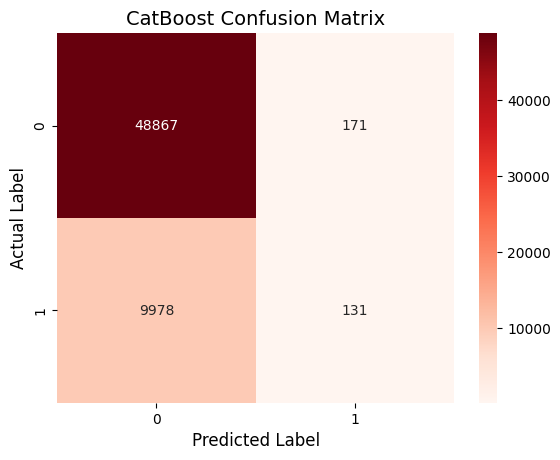

In [376]:
# Accuracy Score 
print("Accuracy Score : ", accuracy_score(ytest,y_pred_cat)*100)

#classification report 
print("Classification Report ", classification_report(ytest,y_pred_cat))

#Confusin Matrix
cm = confusion_matrix(ytest,y_pred_cat)

#Heatmap For Confusion Matrix
sns.heatmap(cm , annot=True , cmap="Reds",fmt='d')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.title("CatBoost Confusion Matrix", fontsize=14)

plt.show()